Mounted at /content/drive
Found 5998 files belonging to 5 classes.
Using 4199 files for training.
Found 5998 files belonging to 5 classes.
Using 1799 files for validation.
Found 5998 files belonging to 5 classes.
Using 4199 files for training.
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.4957 - loss: 1.4009 - val_accuracy: 0.8036 - val_loss: 0.8196
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 75s 564ms/step - accuracy: 0.8797 - loss: 0.7354 - val_accuracy: 0.9286 - val_loss: 0.6015
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 80s 552ms/step - accuracy: 0.9277 - loss: 0.6308 - val_accuracy: 0.9487 - val_loss: 0.5507
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 72s 539ms/step - accuracy: 0.9494 - loss: 0.5860 - val_accuracy: 0.9565 - val_loss: 0.5365
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 70s 530ms/step - accuracy: 0.9595 - loss: 0.5674 - val_accuracy: 0.9498 - val_loss: 0.5427
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 70s 527ms/

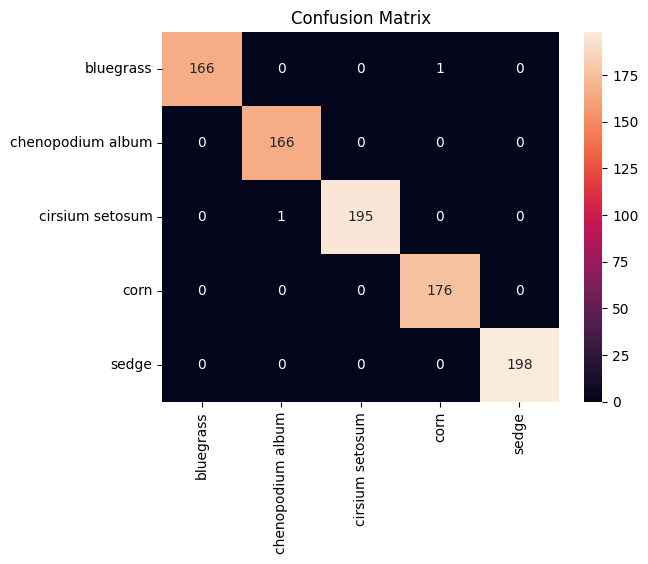

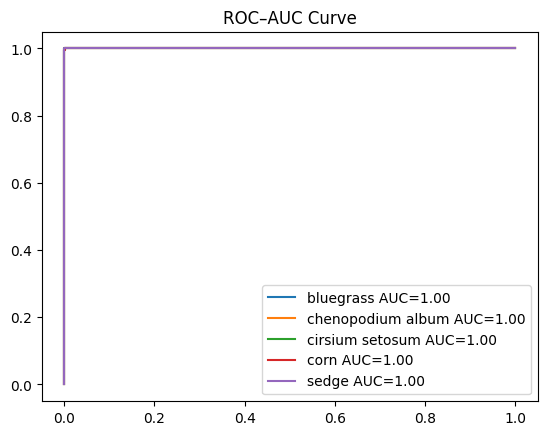


Friedman Statistic: 20.0
p-value: 0.000499

Final Results:
Model               Accuracy   Precision    Recall    F1 Score      Params
--------------------------------------------------------------------------
ConvNeXtV2             99.78       99.78     99.78       99.78    28363976


In [ ]:
# ============================================================
# ConvNeXtV2 + CBAM | FINAL CLEAN SINGLE-RUN PIPELINE
# TF 2.17+ | Keras 3.x | COLAB | PAPER-READY
# ============================================================

import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import keras

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.applications.convnext import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import friedmanchisquare

# ============================================================
# DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ============================================================
# CONFIG
# ============================================================
DATASET_DIR = "/content/drive/MyDrive/corn weed datasets"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS_1 = 15
EPOCHS_2 = 10
NUM_CLASSES = 5
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ============================================================
# DATASET
# ============================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds  = temp_ds.take(len(temp_ds)//2)
test_ds = temp_ds.skip(len(temp_ds)//2)

class_names = train_ds.class_names

# ============================================================
# AUGMENTATION
# ============================================================
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
])

# Apply augmentation and one-hot encoding for training labels
train_ds = train_ds.map(lambda x,y:(augment(x), tf.one_hot(y, depth=NUM_CLASSES))).prefetch(tf.data.AUTOTUNE)
# Apply one-hot encoding for validation labels
val_ds   = val_ds.map(lambda x,y:(x, tf.one_hot(y, depth=NUM_CLASSES))).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)

# ============================================================
# CLASS WEIGHTS
# ============================================================
raw_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

y_train = np.concatenate([y.numpy() for _, y in raw_ds])

# Calculate weights for classes actually present in y_train
unique_y_train = np.unique(y_train)
temp_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_y_train,
    y=y_train
)

# Map the computed weights to the full set of NUM_CLASSES
class_weights_dict = {}
for i in range(NUM_CLASSES):
    if i in unique_y_train:
        # Find the index of i in unique_y_train to get the correct weight
        idx = np.where(unique_y_train == i)[0][0]
        class_weights_dict[i] = temp_weights[idx]
    else:
        # Assign a default weight of 1.0 (no adjustment) for classes not present in y_train
        class_weights_dict[i] = 1.0

class_weights = class_weights_dict

# ============================================================
# CBAM
# ============================================================
def cbam_block(x, ratio=8):
    ch = x.shape[-1]

    avg = layers.GlobalAveragePooling2D()(x)
    maxp = layers.GlobalMaxPooling2D()(x)

    d1 = layers.Dense(ch//ratio, activation="relu", use_bias=False)
    d2 = layers.Dense(ch, use_bias=False)

    ca = layers.Activation("sigmoid")(d2(d1(avg)) + d2(d1(maxp)))
    ca = layers.Reshape((1,1,ch))(ca)
    x = layers.Multiply()([x, ca])

    # Replaced tf.reduce_mean and tf.reduce_max with keras.ops.mean and keras.ops.max
    avg_sp = keras.ops.mean(x, axis=-1, keepdims=True)
    max_sp = keras.ops.max(x, axis=-1, keepdims=True)

    sa = layers.Conv2D(1, 7, padding="same", activation="sigmoid")(
        layers.Concatenate()([avg_sp, max_sp])
    )

    return layers.Multiply()([x, sa])

# ============================================================
# MODEL
# ============================================================
base = ConvNeXtTiny(include_top=False, weights="imagenet")
base.trainable = False

inp = layers.Input((*IMG_SIZE,3))
x = preprocess_input(inp)
x = base(x)
x = cbam_block(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
out = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inp, out)

# ============================================================
# LOSS (LABEL SMOOTHING)
# ============================================================
# Changed to CategoricalCrossentropy with one-hot encoded labels
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# ============================================================
# TRAINING STAGE 1
# ============================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

h1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_1,
    class_weight=class_weights,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)]
)

# ============================================================
# TRAINING STAGE 2 (FINE-TUNE)
# ============================================================
base.trainable = True
for l in base.layers:
    if isinstance(l, layers.BatchNormalization):
        l.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=loss_fn,
    metrics=["accuracy"]
)

h2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_2,
    class_weight=class_weights,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

# ============================================================
# EVALUATION
# ============================================================
y_true, y_pred, y_prob = [], [], []

for x,y in test_ds:
    p = model.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(p,1))
    y_prob.extend(p)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# ROC–AUC
# ============================================================
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
plt.figure()
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
    plt.plot(fpr, tpr, label=f"{class_names[i]} AUC={auc(fpr,tpr):.2f}")
plt.legend()
plt.title("ROC–AUC Curve")
plt.show()

# ============================================================
# FRIEDMAN TEST (FIXED)
# ============================================================
class_acc = []
for i in range(NUM_CLASSES):
    idx = (y_true == i)
    class_acc.append(np.mean(y_pred[idx] == i))

friedman = friedmanchisquare(*[np.repeat(a, 5) for a in class_acc])

print("\nFriedman Statistic:", round(friedman.statistic, 4))
print("p-value:", round(friedman.pvalue, 6))

# ============================================================
# FINAL RESULTS (FORMATTED LIKE SCREENSHOT)
# ============================================================
acc_f = accuracy_score(y_true, y_pred)*100
prec  = precision_score(y_true, y_pred, average="weighted")*100
rec   = recall_score(y_true, y_pred, average="weighted")*100
f1    = f1_score(y_true, y_pred, average="weighted")*100

print("\nFinal Results:")
print(f"{'Model':<18}{'Accuracy':>10}{'Precision':>12}{'Recall':>10}{'F1 Score':>12}{'Params':>12}")
print("-"*74)
print(f"{'ConvNeXtV2':<18}{acc_f:>10.2f}{prec:>12.2f}{rec:>10.2f}{f1:>12.2f}{model.count_params():>12}")


In [ ]:
# ============================================================
# SAVE TRAINED DEEP LEARNING MODEL TO DISK
# ============================================================
# This cell exports the fully-trained model and weights as an .h5 file
model.save("Untitled65.h5")
print("Trained ConvNeXt-Tiny model successfully saved as Untitled65.h5!")